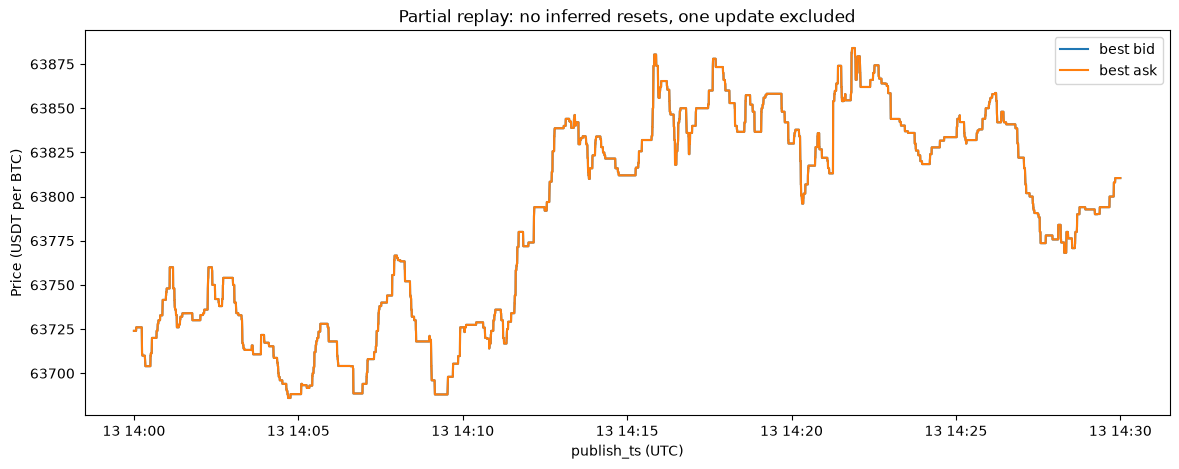

rows,crossed_books
u32,u32
17993,0


In [1]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_parquet("../parquets/D_binance_btcusdt_orderbook_incremental.parquet").sort("seq_id")
bids, asks, states = {}, {}, []

for row in df.filter(pl.col("seq_id") != 98502143047).iter_rows(named=True):
    for book, prices, qtys in [(bids, row["bid_prices"], row["bid_qtys"]), (asks, row["ask_prices"], row["ask_qtys"])]:
        for price, qty in zip(prices, qtys, strict=True):
            book.pop(price, None) if qty == 0 else book.update({price: qty})
    states.append({
        "seq_id": row["seq_id"], "publish_ts": row["publish_ts"],
        "best_bid": max(bids, default=None), "best_ask": min(asks, default=None),
    })

book = pl.DataFrame(states).with_columns(crossed_book=pl.col("best_bid") > pl.col("best_ask"))

plt.figure(figsize=(14, 5))
plt.plot(book["publish_ts"], book["best_bid"], label="best bid")
plt.plot(book["publish_ts"], book["best_ask"], label="best ask")
plt.title("Partial replay: no inferred resets, one update excluded")
plt.xlabel("publish_ts (UTC)")
plt.ylabel("Price (USDT per BTC)")
plt.legend()
plt.show()

book.select(pl.len().alias("rows"), pl.col("crossed_book").sum().alias("crossed_books"))

In [2]:
book.select(pl.len().alias("rows"), pl.col("crossed_book").sum().alias("crossed_books"), pl.lit(len(bids) + len(asks)).alias("final_price_levels"))

rows,crossed_books,final_price_levels
u32,u32,i32
17993,0,3509
